# 1. 平坦时变模型 AD-TLERT GPU 正演

读取 `data/test_model/0_flat_model/resistivity.npy`，建立平坦2.5D正演网格和48电极 Wenner-α 测线，使用 cuDSS 在GPU上计算49个时刻的视电阻率，并加入与误差模型一致的3%乘性噪声（固定随机种子）。这里生成的 `.dat` 是所有后续反演共用的唯一观测数据；本 notebook 不创建反演网格。

## 1. 环境、路径和GPU要求

In [1]:
from pathlib import Path
import json
import os
import time

os.environ.setdefault('ADTLERT_ENABLE_FLOAT64', '1')

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

from adtlert.workflows import (
    ParflowGrid, TerrainForwardRunner, build_terrain_forward_case,
    save_terrain_forward_dat,
)

torch.set_default_dtype(torch.float64)  # after adtlert fixed FLOAT_DTYPE at import

cwd = Path.cwd().resolve()
root = next(path for path in (cwd, *cwd.parents) if (path / 'pyproject.toml').exists())
model_dir = root / 'data/test_model/0_flat_model'
model_file = model_dir / 'resistivity.npy'
metadata_file = model_dir / 'metadata.json'
output_dir = root / 'result/1_forward/0_flat_model'
output_dir.mkdir(parents=True, exist_ok=True)

relative_error = 0.03
noise_level = relative_error  # 观测噪声与误差模型一致
noise_seed = 20261001

assert torch.cuda.is_available(), '这个 notebook 强制要求 CUDA'
print('project root:', root)
print('model file:', model_file)
print('output directory:', output_dir)
print('GPU:', torch.cuda.get_device_name(torch.cuda.current_device()))

project root: /home/luffy/projects/DeepERT
model file: /home/luffy/projects/DeepERT/data/test_model/0_flat_model/resistivity.npy
output directory: /home/luffy/projects/DeepERT/result/1_forward/0_flat_model
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. 读取49时刻电阻率模型

In [2]:
models = np.asarray(np.load(model_file, allow_pickle=False), dtype=np.float64)
model_metadata = json.loads(metadata_file.read_text(encoding='utf-8'))

if models.ndim != 3:
    raise ValueError(f'expected resistivity shape (time, z, x), got {models.shape}')
if tuple(models.shape) != tuple(model_metadata['model_shape']):
    raise ValueError('resistivity.npy shape does not match metadata.json')
if model_metadata['array_vertical_order'] != 'top_to_bottom':
    raise ValueError('this notebook requires top_to_bottom model ordering')
if not np.all(np.isfinite(models)) or np.any(models <= 0.0):
    raise ValueError('resistivity model must be finite and positive')

n_times, nz, nx = models.shape
time_index = np.arange(n_times, dtype=np.int32)
print('model shape:', models.shape)
print('resistivity range:', float(models.min()), float(models.max()), 'ohm-m')

model shape: (49, 24, 94)
resistivity range: 50.0 399.9999999999999 ohm-m


## 3. 建立平坦正演网格和 Wenner-α 测线

网格与模型数组一一对应：水平94列、间距2.5 m；垂向24层、从浅到深总厚度60 m。模型数组是从浅到深，传入现有 terrain helper 时显式翻转为它要求的 bottom-to-top 输入。

In [3]:
dx = 2.5
layer_thickness = np.asarray([1.0] * 8 + [2.0] * 6 + [4.0] * 10, dtype=float)
if layer_thickness.size != nz:
    raise ValueError('vertical grid does not match resistivity.npy')

grid = ParflowGrid(
    dx=dx, dy=dx, dz_base=1.0, nx=nx, ny=1, nz=nz,
    dz_scales=layer_thickness[::-1].copy(),
)
slope_x = np.zeros(nx, dtype=float)
case = build_terrain_forward_case(
    models[0, ::-1, :], grid, slope_x,
    y_index=0, n_electrodes=48, topo_offset=0.0,
)
measurements = np.asarray(case.survey.measurements, dtype=np.int32)
electrodes = np.column_stack((case.elec_x, case.elec_z))

assert case.mesh.cell_count == nx * nz
assert electrodes.shape == (48, 2)
assert measurements.shape == (360, 4)
assert case.mesh.is_flat_surface
print({
    'mesh_cells': int(case.mesh.cell_count),
    'mesh_nodes': int(case.mesh.node_count),
    'electrodes': int(electrodes.shape[0]),
    'measurements': int(measurements.shape[0]),
    'flat_surface': bool(case.mesh.is_flat_surface),
})

{'mesh_cells': 2256, 'mesh_nodes': 2375, 'electrodes': 48, 'measurements': 360, 'flat_surface': True}


## 4. 检查模型、网格和电极位置

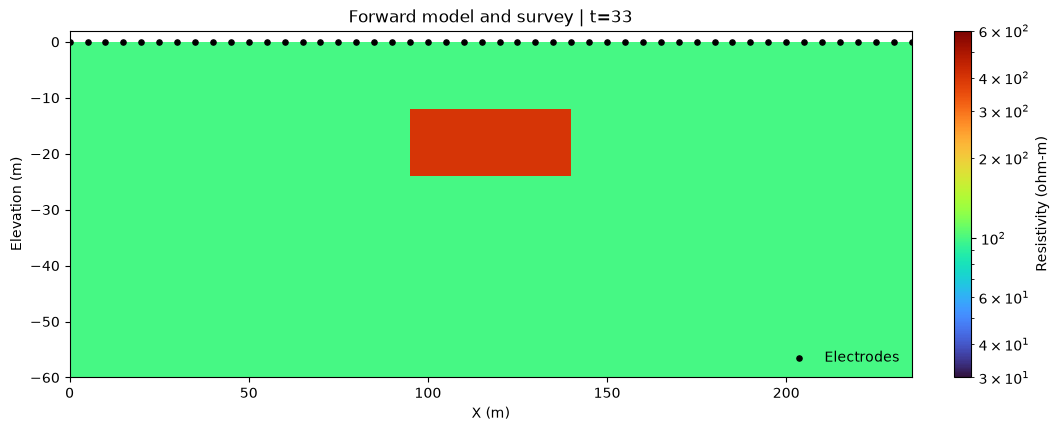

In [4]:
x_edges = np.arange(nx + 1, dtype=float) * dx
z_edges = -np.concatenate(([0.0], np.cumsum(layer_thickness)))
preview_step = 33

fig, ax = plt.subplots(figsize=(10.5, 4.2), constrained_layout=True)
image = ax.pcolormesh(
    x_edges, z_edges, models[preview_step], shading='flat', cmap='turbo',
    norm=LogNorm(vmin=30.0, vmax=600.0),
)
ax.scatter(case.elec_x, case.elec_z, s=14, c='black', zorder=3, label='Electrodes')
ax.set(xlabel='X (m)', ylabel='Elevation (m)', title=f'Forward model and survey | t={preview_step}', ylim=(-60.0, 2.0))
ax.legend(frameon=False, loc='lower right')
fig.colorbar(image, ax=ax, label='Resistivity (ohm-m)')
fig.savefig(output_dir / 'model.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. 使用 cuDSS 在GPU上逐时刻正演

所有时刻共用同一个网格、测线、稀疏模式和 cuDSS solver state。逐时刻执行可以控制显存占用，同时仍然复用GPU缓存。

In [5]:
runner = TerrainForwardRunner.from_case(
    case, reuse_solver_state=True, prepare_forward=True,
)
clean = np.empty((n_times, measurements.shape[0]), dtype=np.float64)
try:
    uniform_rhoa = runner.solve_resistivity(np.full(case.mesh.cell_count, 100.0, dtype=np.float64))
    uniform_boundary_error = np.abs(uniform_rhoa - 100.0) / 100.0
    if np.median(uniform_boundary_error) >= 0.005 or uniform_boundary_error.max() >= 0.02:
        raise RuntimeError('60 m forward boundary validation failed')

    started = time.perf_counter()
    for step in range(n_times):
        clean[step] = runner.solve_resistivity(models[step].reshape(-1))
        if step % 8 == 0 or step == n_times - 1:
            print(f't={step:02d}/{n_times - 1}: rhoa={clean[step].min():.3f}–{clean[step].max():.3f} ohm-m')
    torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - started
    gpu_report = {
        'cuda_available': bool(torch.cuda.is_available()),
        'device_index': int(torch.cuda.current_device()),
        'device_name': torch.cuda.get_device_name(torch.cuda.current_device()),
    }
finally:
    runner.close()

assert clean.shape == (49, 360)
assert np.all(np.isfinite(clean)) and np.all(clean > 0.0)
baseline_rhoa = clean[0]
print('GPU report:', gpu_report)
print(f'elapsed={elapsed_seconds:.3f} s, per step={elapsed_seconds / n_times:.3f} s')
print(f'uniform boundary error: median={np.median(uniform_boundary_error):.3%}, max={uniform_boundary_error.max():.3%}')
print(f'baseline response: {baseline_rhoa.min():.3f}–{baseline_rhoa.max():.3f} ohm-m')

t=00/48: rhoa=86.501–100.008 ohm-m
t=08/48: rhoa=99.907–114.020 ohm-m
t=16/48: rhoa=99.907–114.020 ohm-m
t=24/48: rhoa=86.501–100.008 ohm-m
t=32/48: rhoa=99.907–114.038 ohm-m
t=40/48: rhoa=99.907–114.038 ohm-m
t=48/48: rhoa=86.501–100.008 ohm-m
GPU report: {'cuda_available': True, 'device_index': 0, 'device_name': 'NVIDIA GeForce RTX 5060 Laptop GPU', 'linear_solver_backend': 'cudss', 'cudss_gpu_enabled': True, 'cudss_zero_copy': False}
elapsed=2.158 s, per step=0.044 s
uniform boundary error: median=0.022%, max=0.141%
baseline response: 86.501–100.008 ohm-m


## 6. 加入观测噪声并逐时刻保存

观测数据为 `observed = clean · exp(σ·n)`，其中 `n` 为各时刻、各测点独立的标准正态随机数，`σ = log(1 + 0.03)`。它与 `.dat` 中的 `err=0.03` 以及反演使用的对数数据误差 `log1p(err)` 一致，因此真模型的期望 χ² ≈ 1，后续反演可按 discrepancy principle 在 χ² ≈ 1 处停止。随机种子固定，所有反演读取同一组观测。

每个时刻只保存一个 `.dat` 观测文件（覆盖旧文件）；公共几何仍单独保存在 `forward_geometry.npz`，噪声设置记录在 `forward_summary.json`。

In [6]:
for obsolete_name in (
    'clean.npy', 'observed.npy', 'data_std.npy', 'measurements.npy',
    'electrodes.npy', 'summary.json',
):
    (output_dir / obsolete_name).unlink(missing_ok=True)
for obsolete_npz in output_dir.glob('synthetic_ert_terrain_vardz_t*.npz'):
    obsolete_npz.unlink()

rng = np.random.default_rng(noise_seed)
noise_sigma = float(np.log1p(noise_level))
observed = clean * np.exp(noise_sigma * rng.standard_normal(clean.shape))
noise_chi2 = float(np.mean((np.log(observed / clean) / np.log1p(relative_error)) ** 2))
assert np.all(np.isfinite(observed)) and np.all(observed > 0.0)
print(f'noise: sigma(log)={noise_sigma:.5f}, realized chi2 of the true model = {noise_chi2:.4f}')

manifest = []
for step in range(n_times):
    stem = f'synthetic_ert_terrain_vardz_t{step:05d}'
    dat_file = output_dir / f'{stem}.dat'
    save_terrain_forward_dat(dat_file, case, observed[step], relative_error=relative_error)
    manifest.append({
        'step': int(step),
        'input_file': f'{model_file}[{step}]',
        'dat_file': str(dat_file),
        'status': 'ok',
        'rhoa_min': float(observed[step].min()),
        'rhoa_max': float(observed[step].max()),
        'error': None,
    })

geometry_file = output_dir / 'forward_geometry.npz'
np.savez(
    geometry_file,
    x_nodes=case.x_nodes, z_top=case.z_top, layer_thickness=case.layer_thickness,
    elec_x=case.elec_x, elec_z=case.elec_z,
    y_index=np.asarray([case.y_index], dtype=np.int32),
    first_step=np.asarray([0], dtype=np.int32),
    DX=np.asarray([grid.dx]), DY=np.asarray([grid.dy]), DZ_BASE=np.asarray([grid.dz_base]),
    NX=np.asarray([grid.nx], dtype=np.int32),
    NY=np.asarray([grid.ny], dtype=np.int32),
    NZ=np.asarray([grid.nz], dtype=np.int32),
    scheme_name=np.asarray(['wa']),
    n_electrodes=np.asarray([len(case.elec_x)], dtype=np.int32),
)

summary = {
    'input_file': str(model_file),
    'output_dir': str(output_dir),
    'n_selected': int(n_times), 'n_ok': int(n_times), 'n_failed': 0,
    'first_step': 0, 'last_step': int(n_times - 1), 'y_index': int(case.y_index),
    'n_electrodes': int(electrodes.shape[0]),
    'scheme_name': 'wa',
    'measurements': int(measurements.shape[0]),
    'mesh_cells': int(case.mesh.cell_count),
    'mesh_nodes': int(case.mesh.node_count),
    'relative_error': relative_error,
    'noise_model': 'observed = clean * exp(log1p(noise_level) * N(0, 1)), iid over time and measurement',
    'noise_level': noise_level,
    'noise_seed': noise_seed,
    'true_model_noise_chi2': noise_chi2,
    'geometry_file': str(geometry_file),
    'save_per_step': '.dat',
    'reuse_solver_state': True,
    'elapsed_sec': elapsed_seconds,
    'elapsed_min': elapsed_seconds / 60.0,
    'seconds_per_step': elapsed_seconds / n_times,
    'rhoa_min': float(observed.min()), 'rhoa_max': float(observed.max()),
    'clean_rhoa_min': float(clean.min()), 'clean_rhoa_max': float(clean.max()),
    'baseline_rhoa_min': float(baseline_rhoa.min()),
    'baseline_rhoa_max': float(baseline_rhoa.max()),
    'baseline_rhoa_median': float(np.median(baseline_rhoa)),
    'uniform_boundary_median_relative_error': float(np.median(uniform_boundary_error)),
    'uniform_boundary_max_relative_error': float(uniform_boundary_error.max()),
    'gpu': gpu_report,
}
(output_dir / 'forward_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
(output_dir / 'forward_failures.json').write_text('[]\n', encoding='utf-8')
(output_dir / 'forward_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))

noise: sigma(log)=0.02956, realized chi2 of the true model = 1.0018
{
  "input_file": "/home/luffy/projects/DeepERT/data/test_model/0_flat_model/resistivity.npy",
  "output_dir": "/home/luffy/projects/DeepERT/result/1_forward/0_flat_model",
  "n_selected": 49,
  "n_ok": 49,
  "n_failed": 0,
  "first_step": 0,
  "last_step": 48,
  "y_index": 0,
  "n_electrodes": 48,
  "scheme_name": "wa",
  "measurements": 360,
  "mesh_cells": 2256,
  "mesh_nodes": 2375,
  "relative_error": 0.03,
  "noise_model": "observed = clean * exp(log1p(noise_level) * N(0, 1)), iid over time and measurement",
  "noise_level": 0.03,
  "noise_seed": 20261001,
  "true_model_noise_chi2": 1.001846634443148,
  "geometry_file": "/home/luffy/projects/DeepERT/result/1_forward/0_flat_model/forward_geometry.npz",
  "save_per_step": ".dat",
  "linear_solver_backend": "cudss",
  "reuse_solver_state": true,
  "elapsed_sec": 2.1579162400012137,
  "elapsed_min": 0.035965270666686894,
  "seconds_per_step": 0.04403910693880028,
  "

## 7. 检查时移正演响应

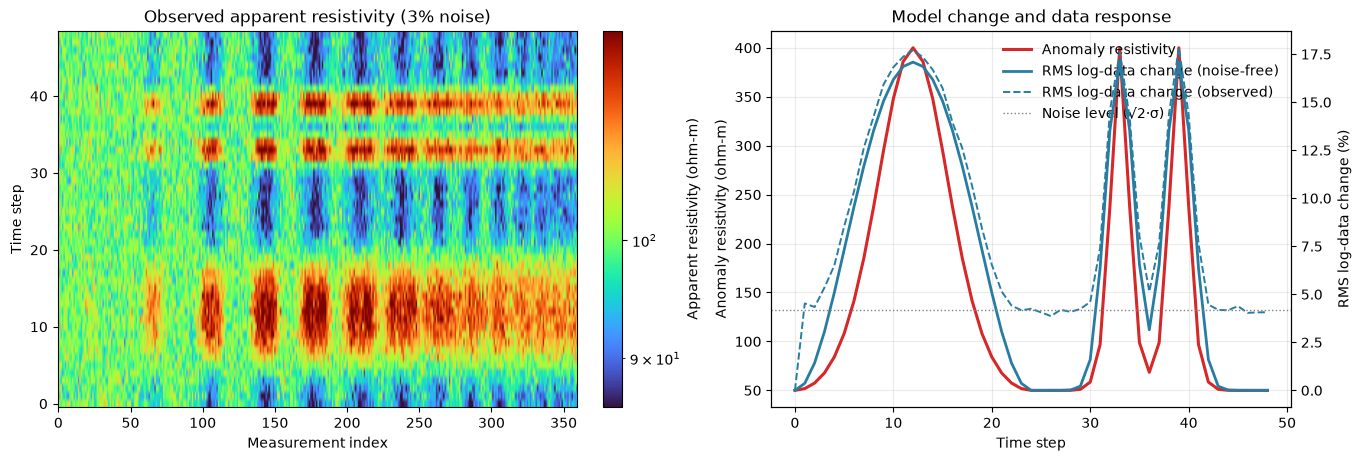

In [7]:
bounds = model_metadata['anomaly_bounds']
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])
xx, zz = np.meshgrid(x_centers, z_centers)
anomaly_region = (
    (xx >= bounds['x_min']) & (xx <= bounds['x_max'])
    & (-zz >= bounds['depth_min']) & (-zz <= bounds['depth_max'])
)
anomaly_curve = models[:, anomaly_region].mean(axis=1)
signal_change = 100.0 * np.sqrt(np.mean(np.log(clean / clean[0]) ** 2, axis=1))
observed_change = 100.0 * np.sqrt(np.mean(np.log(observed / observed[0]) ** 2, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
vmin, vmax = np.quantile(observed, [0.01, 0.99])
image = axes[0].imshow(
    observed, aspect='auto', origin='lower', cmap='turbo',
    norm=LogNorm(vmin=float(vmin), vmax=float(vmax)),
    extent=(-0.5, measurements.shape[0] - 0.5, -0.5, n_times - 0.5),
)
axes[0].set(xlabel='Measurement index', ylabel='Time step', title='Observed apparent resistivity (3% noise)')
fig.colorbar(image, ax=axes[0], label='Apparent resistivity (ohm-m)')

axes[1].plot(time_index, anomaly_curve, color='#d62828', linewidth=2.2, label='Anomaly resistivity')
axes[1].set(xlabel='Time step', ylabel='Anomaly resistivity (ohm-m)', title='Model change and data response')
axes[1].grid(alpha=0.25)
response_axis = axes[1].twinx()
response_axis.plot(time_index, signal_change, color='#277da1', linewidth=2.0, label='RMS log-data change (noise-free)')
response_axis.plot(time_index, observed_change, color='#277da1', linewidth=1.4, linestyle='--', label='RMS log-data change (observed)')
response_axis.axhline(100.0 * np.sqrt(2.0) * np.log1p(noise_level), color='0.5', linewidth=1.0, linestyle=':', label='Noise level (√2·σ)')
response_axis.set_ylabel('RMS log-data change (%)')
lines = axes[1].lines + response_axis.lines
axes[1].legend(lines, [line.get_label() for line in lines], frameon=False, loc='upper right')
plt.show()

## 8. 最终文件

后续反演按 `synthetic_ert_terrain_vardz_t*.dat` 读取49个时刻；`forward_geometry.npz` 保存公共几何，manifest 和 summary 记录运行状态。

In [8]:
for path in sorted(output_dir.iterdir()):
    print(f'{path.name:20s} {path.stat().st_size:>10d} bytes')

forward_failures.json          3 bytes
forward_geometry.npz       6230 bytes
forward_manifest.json      17121 bytes
forward_summary.json       1558 bytes
model.png                 61861 bytes
synthetic_ert_terrain_vardz_t00000.dat      65753 bytes
synthetic_ert_terrain_vardz_t00001.dat      65753 bytes
synthetic_ert_terrain_vardz_t00002.dat      65753 bytes
synthetic_ert_terrain_vardz_t00003.dat      65753 bytes
synthetic_ert_terrain_vardz_t00004.dat      65753 bytes
synthetic_ert_terrain_vardz_t00005.dat      65753 bytes
synthetic_ert_terrain_vardz_t00006.dat      65753 bytes
synthetic_ert_terrain_vardz_t00007.dat      65753 bytes
synthetic_ert_terrain_vardz_t00008.dat      65753 bytes
synthetic_ert_terrain_vardz_t00009.dat      65753 bytes
synthetic_ert_terrain_vardz_t00010.dat      65753 bytes
synthetic_ert_terrain_vardz_t00011.dat      65753 bytes
synthetic_ert_terrain_vardz_t00012.dat      65753 bytes
synthetic_ert_terrain_vardz_t00013.dat      65753 bytes
synthetic_ert_terrain_va